module://matplotlib_inline.backend_inline


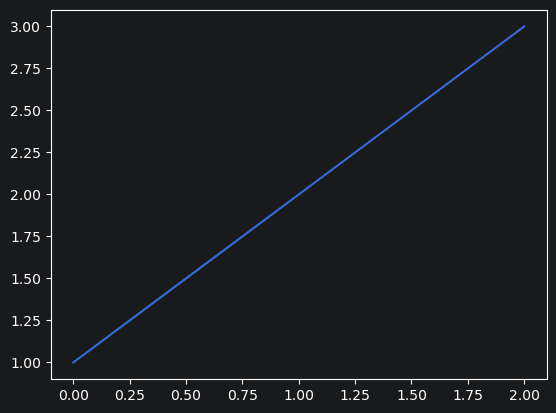

finished


In [25]:
%matplotlib inline

import matplotlib

matplotlib.rcParams['backend'] = 'module://matplotlib_inline.backend_inline'

import matplotlib.pyplot as plt

print(matplotlib.get_backend())
plt.clf()
plt.plot([1,2,3])
plt.show()
print("finished")

In [26]:
import torch
from src.model import SequenceCNN

model = SequenceCNN()

model.load_state_dict(
    torch.load(
        "../models/liver_accessibility_cnn.pth"
    )
)

model.eval()

SequenceCNN(
  (conv1): Conv1d(4, 32, kernel_size=(11,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [27]:
import pandas as pd

dataset_df = pd.read_csv(
    "../data/processed/liver_accessibility_gc_matched.csv"
)

In [28]:
from src.datasets import SequenceDataset

dataset = SequenceDataset(
    "../data/processed/liver_accessibility_gc_matched.csv"
)

In [30]:
KERNEL_SIZE = 11
top_motifs = []

for FILTER_INDEX in range(32):
    for i in range(1000):

        sample_x, sample_y, chrom = dataset[i]

        sample_x = sample_x.unsqueeze(0)

        conv_output = model.conv1(sample_x)

        activations = (
            conv_output[
                0,
                FILTER_INDEX
            ]
            .detach()
            .numpy()
        )

        max_position = activations.argmax()

        max_activation = activations.max()

        sequence = dataset_df.iloc[i]["sequence"]

        motif_candidate = sequence[
            max_position:max_position + KERNEL_SIZE
        ]

        top_motifs.append({
            "motif": motif_candidate,
            "activation": max_activation
        })

In [31]:
top_motifs = sorted(
    top_motifs,
    key=lambda x: x["activation"],
    reverse=True
)

In [32]:
for entry in top_motifs[:20]:

    print(
        entry["motif"],
        entry["activation"]
    )

CAGGATGGTCT 3.4385657
CAGGATGGTCT 3.4385657
CAGGATGGTCT 3.4385657
CTCCATCTCAA 3.4118695
CAAGGTGGTCT 3.3356502
GTGGGGGTCCC 3.330897
GACCATCTTGG 3.3206031
CAGGATGGTGT 3.2918568
CATGGTGGTGT 3.2827108
CATGGTGGTGT 3.2827108
GTGGGGGTCCA 3.2405653
TAAGATGGTCC 3.236068
ATGGGGGGCCC 3.1837466
CAGGCCCCCCA 3.1733038
CTCCATCTCCA 3.16457
CTCCATCTCCA 3.16457
CAAGATGGTGA 3.1542284
GACCATCCTGG 3.154139
GACCATCCTGG 3.154139
CATGTTGGTGT 3.1254625


In [33]:
seen = set()

unique_top_motifs = []

for entry in top_motifs:

    motif = entry["motif"]

    if motif not in seen:

        unique_top_motifs.append(entry)

        seen.add(motif)

In [34]:
for entry in unique_top_motifs[:20]:

    print(
        entry["motif"],
        entry["activation"]
    )

CAGGATGGTCT 3.4385657
CTCCATCTCAA 3.4118695
CAAGGTGGTCT 3.3356502
GTGGGGGTCCC 3.330897
GACCATCTTGG 3.3206031
CAGGATGGTGT 3.2918568
CATGGTGGTGT 3.2827108
GTGGGGGTCCA 3.2405653
TAAGATGGTCC 3.236068
ATGGGGGGCCC 3.1837466
CAGGCCCCCCA 3.1733038
CTCCATCTCCA 3.16457
CAAGATGGTGA 3.1542284
GACCATCCTGG 3.154139
CATGTTGGTGT 3.1254625
GTGGGGGTCCT 3.123924
CCACATCTCAA 3.1191652
GATGGGGTCCC 3.1183555
CAGCCTCCCTA 3.0983517
CTCCATCTTAA 3.0982287


In [35]:
top_sequences = [
    entry["motif"]
    for entry in unique_top_motifs[:100]
]

In [36]:
import numpy as np

pfm = np.zeros((4, KERNEL_SIZE)) #Position Frequency Matrix

nucleotide_to_index = {
    "A": 0,
    "C": 1,
    "G": 2,
    "T": 3
}

for sequence in top_sequences:

    for position, nucleotide in enumerate(sequence):

        row = nucleotide_to_index[
            nucleotide
        ]

        pfm[row, position] += 1

pfm = pfm / pfm.sum(axis=0)

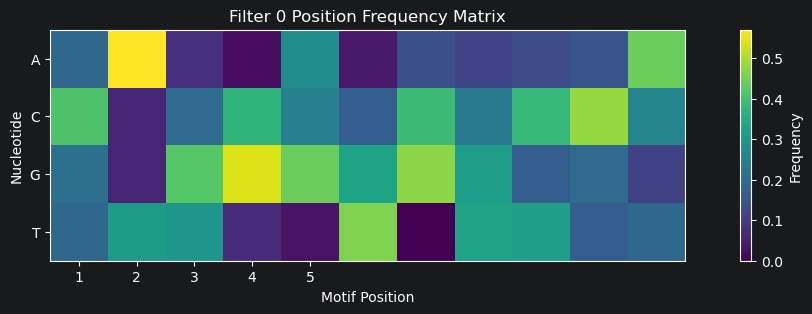

In [37]:
plt.figure(figsize=(14, 3))

plt.imshow(pfm)

plt.yticks(
    [0, 1, 2, 3],
    ["A", "C", "G", "T"]
)

plt.xticks(
    range(5),
    range(1, 6)
)

plt.xlabel("Motif Position")
plt.ylabel("Nucleotide")

plt.colorbar(label="Frequency")

plt.title("Filter 0 Position Frequency Matrix")

plt.show()

In [38]:
pwd

'C:\\Users\\dwhip\\PycharmProjects\\chromatintune\\notebooks'

In [ ]:
KERNEL_SIZE = 11
top_motifs = []

nucleotide_to_index = {
    "A": 0,
    "C": 1,
    "G": 2,
    "T": 3
}



for FILTER_INDEX in range(32):
    for i in range(1000):

        sample_x, sample_y, chrom = dataset[i]

        sample_x = sample_x.unsqueeze(0)

        conv_output = model.conv1(sample_x)

        activations = (
            conv_output[
                0,
                FILTER_INDEX
            ]
            .detach()
            .numpy()
        )

        max_position = activations.argmax()

        max_activation = activations.max()

        sequence = dataset_df.iloc[i]["sequence"]

        motif_candidate = sequence[
            max_position:max_position + KERNEL_SIZE
        ]

        top_motifs.append({
            "motif": motif_candidate,
            "activation": max_activation
        })

    top_motifs = sorted(
    top_motifs,
    key=lambda x: x["activation"],
    reverse=True
    )

    seen = set()

    unique_top_motifs = []

    for entry in top_motifs:

        motif = entry["motif"]

        if motif not in seen:

            unique_top_motifs.append(entry)

            seen.add(motif)

    top_sequences = [
        entry["motif"]
        for entry in unique_top_motifs[:100]
    ]

    pfm = np.zeros((4, KERNEL_SIZE))

    for sequence in top_sequences:

        for position, nucleotide in enumerate(sequence):

            row = nucleotide_to_index[
                nucleotide
            ]

            pfm[row, position] += 1

    pfm = pfm / pfm.sum(axis=0)

    plt.figure(figsize=(14, 3))

    plt.imshow(pfm)

    plt.yticks(
        [0, 1, 2, 3],
        ["A", "C", "G", "T"]
    )

    plt.xticks(
        range(KERNEL_SIZE),
        range(1, KERNEL_SIZE+1)
    )

    plt.xlabel("Motif Position")
    plt.ylabel("Nucleotide")

    plt.colorbar(label="Frequency")

    plt.title(f"Filter {FILTER_INDEX} Position Frequency Matrix")

    plt.savefig(f"../figures/filter{FILTER_INDEX}")

    top_motifs = []



